In [2]:
import pandas as pd

# 1. Cargar los datos (agregamos low_memory=False para evitar warnings de Dtype)
ruta_t1 = r"C:\Users\Yaveh\Desktop\Investigación cora\conjunto_de_datos_enoe_2025_1t_csv\conjunto_de_datos_sdem_enoe_2025_1t\conjunto_de_datos\conjunto_de_datos_sdem_enoe_2025_1t.csv"
ruta_t2 = r"C:\Users\Yaveh\Desktop\Investigación cora\conjunto_de_datos_enoe_2025_2t_csv\conjunto_de_datos_sdem_enoe_2025_2t\conjunto_de_datos\conjunto_de_datos_sdem_enoe_2025_2t.csv"
ruta_t3 = r"C:\Users\Yaveh\Desktop\Investigación cora\conjunto_de_datos_enoe_2025_3t_csv\conjunto_de_datos_sdem_enoe_2025_3t\conjunto_de_datos\conjunto_de_datos_sdem_enoe_2025_3t.csv"
ruta_t4 = r"C:\Users\Yaveh\Desktop\Investigación cora\conjunto_de_datos_enoe_2025_4t_csv\conjunto_de_datos_sdem_enoe_2025_4t\conjunto_de_datos\conjunto_de_datos_sdem_enoe_2025_4t.csv"

t1 = pd.read_csv(ruta_t1, encoding='latin1', low_memory=False)
t2 = pd.read_csv(ruta_t2, encoding='latin1', low_memory=False)
t3 = pd.read_csv(ruta_t3, encoding='latin1', low_memory=False)
t4 = pd.read_csv(ruta_t4, encoding='latin1', low_memory=False)

# 2. Estandarizar nombres de columnas a minúsculas (INEGI a veces cambia esto entre trimestres)
t1.columns = t1.columns.str.lower()
t2.columns = t2.columns.str.lower()
t3.columns = t3.columns.str.lower()
t4.columns = t4.columns.str.lower()

# 3. Definir las llaves primarias que identifican a un individuo único a través del tiempo
llaves_panel = ['cd_a', 'ent', 'con', 'v_sel', 'n_hog', 'h_mud', 'n_ren']

# 4. Definir las variables de interés sociodemográficas y laborales
# clase1: 1 = PEA, 2 = PNEA (Inactivo)
# clase2: 1 = Ocupado, 2 = Desocupado
# fac_tri: Factor de expansión para que los datos representen a toda la población
cols_interes = llaves_panel + ['eda', 'clase1', 'clase2', 'fac_tri']

# Filtrar los DataFrames desde el inicio ahorra muchísima memoria
t1_filtrado = t1[cols_interes].copy()
t2_filtrado = t2[cols_interes].copy()
t3_filtrado = t3[cols_interes].copy()
t4_filtrado = t4[cols_interes].copy()

# 5. Hacer el "Merge" (Inner Join) para quedarnos SOLO con las personas que aparecen en ambos trimestres
panel = pd.merge(t1_filtrado, t2_filtrado, on=llaves_panel, suffixes=('_t1', '_t2'), how='inner')

# 6. Limpieza de consistencia y demografía
# Forzamos la convención del modelo de Guildford: Población en edad de trabajar (16 a 64 años)
# Nota: La edad ('eda') en INEGI puede venir como texto, la forzamos a numérico
panel['eda_t1'] = pd.to_numeric(panel['eda_t1'], errors='coerce')
panel['eda_t2'] = pd.to_numeric(panel['eda_t2'], errors='coerce')
panel['eda_t3'] = pd.to_numeric(panel['eda_t3'], errors='coerce')
panel['eda_t4'] = pd.to_numeric(panel['eda_t4'], errors='coerce')

panel = panel[(panel['eda_t1'] >= 16) & (panel['eda_t1'] <= 64)]

# Verificación de identidad: La edad de la persona no debería brincar más de 1 año entre un trimestre y otro
panel = panel[abs(panel['eda_t2'] - panel['eda_t1']) <= 1]

print(f"¡Éxito! Tamaño de la muestra en panel: {len(panel)} individuos rastreados del T1 al T2.")

KeyError: "['ent'] not in index"

In [4]:
import pandas as pd

ruta_t1 = r"C:\Users\Yaveh\Desktop\Investigación cora\conjunto_de_datos_enoe_2025_1t_csv\conjunto_de_datos_sdem_enoe_2025_1t\conjunto_de_datos\conjunto_de_datos_sdem_enoe_2025_1t.csv"
ruta_t2 = r"C:\Users\Yaveh\Desktop\Investigación cora\conjunto_de_datos_enoe_2025_2t_csv\conjunto_de_datos_sdem_enoe_2025_2t\conjunto_de_datos\conjunto_de_datos_sdem_enoe_2025_2t.csv"
ruta_t3 = r"C:\Users\Yaveh\Desktop\Investigación cora\conjunto_de_datos_enoe_2025_3t_csv\conjunto_de_datos_sdem_enoe_2025_3t\conjunto_de_datos\conjunto_de_datos_sdem_enoe_2025_3t.csv"
ruta_t4 = r"C:\Users\Yaveh\Desktop\Investigación cora\conjunto_de_datos_enoe_2025_4t_csv\conjunto_de_datos_sdem_enoe_2025_4t\conjunto_de_datos\conjunto_de_datos_sdem_enoe_2025_4t.csv"

t1 = pd.read_csv(ruta_t1, encoding='latin1', low_memory=False)
t2 = pd.read_csv(ruta_t2, encoding='latin1', low_memory=False)
t3 = pd.read_csv(ruta_t3, encoding='latin1', low_memory=False)
t4 = pd.read_csv(ruta_t4, encoding='latin1', low_memory=False)

# 2. Estandarizar nombres de columnas y limpiar espacios ocultos
for df in [t1, t2, t3, t4]:
    # Quitamos espacios en blanco al inicio/final y pasamos a minúsculas
    df.columns = df.columns.str.strip().str.lower()
    
    # Si INEGI le puso 'cve_ent' (como descubriste) o 'entidad', lo renombramos a 'ent'
    if 'cve_ent' in df.columns:
        df.rename(columns={'cve_ent': 'ent'}, inplace=True)
    elif 'entidad' in df.columns:
        df.rename(columns={'entidad': 'ent'}, inplace=True)
        
    # Convertimos la edad a numérico DESDE AHORA para evitar errores futuros
    df['eda'] = pd.to_numeric(df['eda'], errors='coerce')

# 3. Definir llaves y variables de interés
llaves_panel = ['cd_a', 'ent', 'con', 'v_sel', 'n_hog', 'h_mud', 'n_ren']
cols_interes = llaves_panel + ['eda', 'clase1', 'clase2', 'fac_tri', 'ing_x_hrs']

# 4. Filtrar y limpiar por edad (16 a 64 años) ANTES de unir
# Esto hará que el proceso de Merge consuma mucha menos memoria
t1_filtrado = t1[cols_interes][(t1['eda'] >= 16) & (t1['eda'] <= 64)].copy()
t2_filtrado = t2[cols_interes][(t2['eda'] >= 16) & (t2['eda'] <= 64)].copy()
t3_filtrado = t3[cols_interes][(t3['eda'] >= 16) & (t3['eda'] <= 64)].copy()
t4_filtrado = t4[cols_interes][(t4['eda'] >= 16) & (t4['eda'] <= 64)].copy()

# 5. Hacer los Merges secuenciales
# Unimos T1 y T2
panel_t1_t2 = pd.merge(t1_filtrado, t2_filtrado, on=llaves_panel, suffixes=('_t1', '_t2'), how='inner')

# Unimos con T3 (necesitamos sufijos manuales porque pandas solo soporta 2 sufijos por defecto)
panel_t1_t2_t3 = pd.merge(panel_t1_t2, t3_filtrado, on=llaves_panel, how='inner')
panel_t1_t2_t3 = panel_t1_t2_t3.rename(columns={'eda': 'eda_t3', 'clase1': 'clase1_t3', 'clase2': 'clase2_t3', 'fac_tri': 'fac_tri_t3'})

# Unimos con T4
panel_final = pd.merge(panel_t1_t2_t3, t4_filtrado, on=llaves_panel, how='inner')
panel_final = panel_final.rename(columns={'eda': 'eda_t4', 'clase1': 'clase1_t4', 'clase2': 'clase2_t4', 'fac_tri': 'fac_tri_t4'})

# 6. Verificación de identidad: La edad no debería brincar más de 1 año entre T1 y T4
panel_final = panel_final[abs(panel_final['eda_t4'] - panel_final['eda_t1']) <= 1]

print(f"¡Éxito! Tamaño de la muestra en panel anual (T1 a T4): {len(panel_final)} individuos rastreados.")

¡Éxito! Tamaño de la muestra en panel anual (T1 a T4): 80227 individuos rastreados.


--- MATRIZ DE TRANSICIÓN (%) DE T1 A T2 ---
estado_t2    Empleado  Desempleado  Inactivo
estado_t1                                   
Empleado        88.98         1.39      9.63
Desempleado     54.29        14.64     31.07
Inactivo        20.40         1.69     77.91


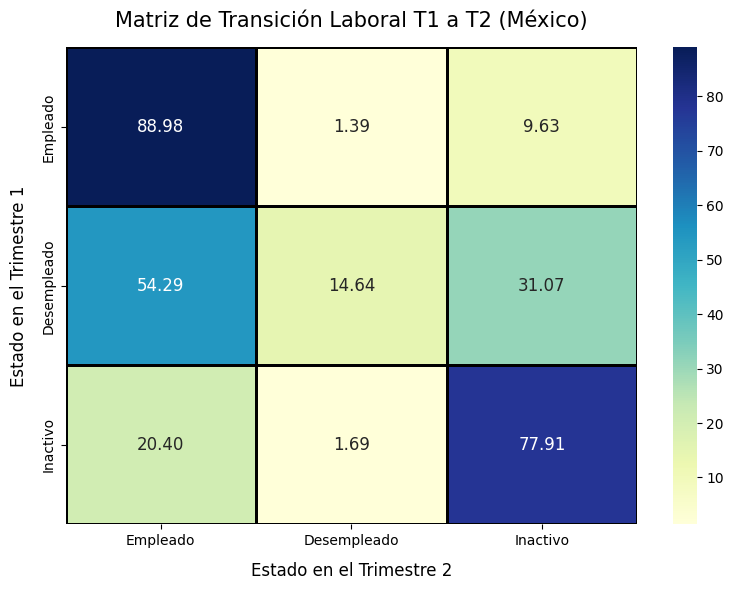

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definir la función para clasificar el estado laboral
# clase1: 1 = Población Económicamente Activa (PEA), 2 = No Activa (PNEA / Inactivo)
# clase2: 1 = Ocupado, 2 = Desocupado
def clasificar_estado(c1, c2):
    if c1 == 1 and c2 == 1:
        return 'Empleado'
    elif c1 == 1 and c2 == 2:
        return 'Desempleado'
    elif c1 == 2:
        return 'Inactivo'
    else:
        return 'Otro'

# 2. Aplicar la clasificación a cada trimestre en tu panel_final
# Asegúrate de que tu dataframe se llame panel_final (o ajusta el nombre según lo tengas)
panel_final['estado_t1'] = panel_final.apply(lambda x: clasificar_estado(x['clase1_t1'], x['clase2_t1']), axis=1)
panel_final['estado_t2'] = panel_final.apply(lambda x: clasificar_estado(x['clase1_t2'], x['clase2_t2']), axis=1)
# También lo dejamos listo para t3 y t4 por si quieres ver la evolución de todo el año
panel_final['estado_t3'] = panel_final.apply(lambda x: clasificar_estado(x['clase1_t3'], x['clase2_t3']), axis=1)
panel_final['estado_t4'] = panel_final.apply(lambda x: clasificar_estado(x['clase1_t4'], x['clase2_t4']), axis=1)

# Filtramos por si acaso quedó algún "Otro" (datos nulos o mal capturados por INEGI)
panel_limpio = panel_final[(panel_final['estado_t1'] != 'Otro') & (panel_final['estado_t2'] != 'Otro')]

# 3. Crear la Matriz de Transición (Probabilidades T1 -> T2)
# normalize='index' calcula el porcentaje por fila (cuántos del estado X pasaron al estado Y)
matriz_transicion = pd.crosstab(
    panel_limpio['estado_t1'], 
    panel_limpio['estado_t2'], 
    normalize='index'
) * 100 

# Reordenamos para que se lea más lógico
orden = ['Empleado', 'Desempleado', 'Inactivo']
matriz_transicion = matriz_transicion.reindex(index=orden, columns=orden)

print("--- MATRIZ DE TRANSICIÓN (%) DE T1 A T2 ---")
print(matriz_transicion.round(2))

# 4. Visualizar la Matriz con un Mapa de Calor (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_transicion, annot=True, fmt=".2f", cmap="YlGnBu", cbar=True, 
            annot_kws={"size": 12}, linewidths=1, linecolor='black')

plt.title('Matriz de Transición Laboral T1 a T2 (México)', fontsize=15, pad=15)
plt.xlabel('Estado en el Trimestre 2', fontsize=12, labelpad=10)
plt.ylabel('Estado en el Trimestre 1', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

--- MATRIZ DE TRANSICIÓN SALARIAL (%) DE T1 A T2 ---
rango_t2     Bajo  Medio-Bajo  Medio  Medio-Alto   Alto
rango_t1                                               
Bajo        53.85       21.59  12.79        6.27   5.49
Medio-Bajo  25.77       32.37  22.57       13.02   6.27
Medio       12.29       23.47  33.41       20.71  10.11
Medio-Alto   8.14       11.51  23.27       34.96  22.12
Alto         6.12        6.61  10.45       20.95  55.87


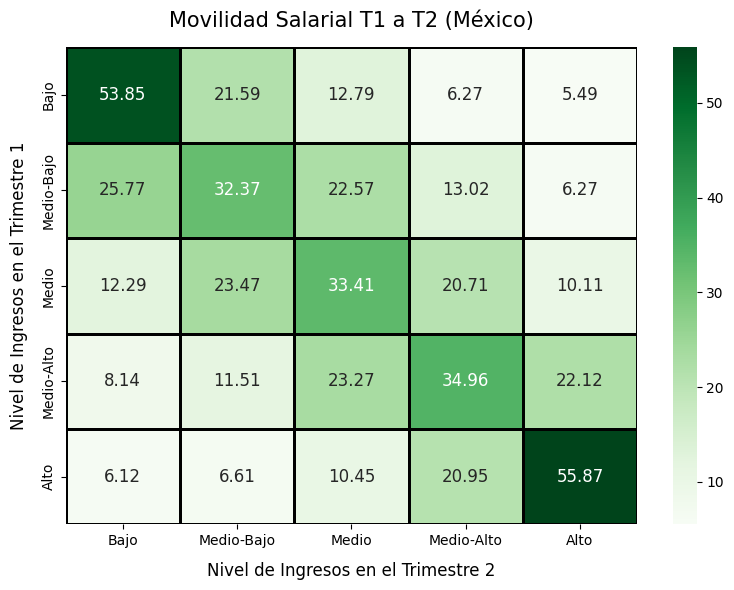

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtrar la base
# Solo nos interesan las personas que tuvieron un salario mayor a 0 en AMBOS trimestres
# (Es decir, que se mantuvieron ocupados y cobrando)
panel_salarios = panel_final[
    (panel_final['ing_x_hrs_t1'] > 0) & 
    (panel_final['ing_x_hrs_t2'] > 0)
].copy()

# 2. Crear las "cajas" o rangos salariales (Quintiles)
# La función pd.qcut divide automáticamente los salarios en 5 grupos del mismo tamaño (20% de la gente en cada uno)
etiquetas_salario = ['Bajo', 'Medio-Bajo', 'Medio', 'Medio-Alto', 'Alto']

# Agrupamos los salarios del T1
panel_salarios['rango_t1'] = pd.qcut(panel_salarios['ing_x_hrs_t1'], q=5, labels=etiquetas_salario, duplicates='drop')

# Agrupamos los salarios del T2
panel_salarios['rango_t2'] = pd.qcut(panel_salarios['ing_x_hrs_t2'], q=5, labels=etiquetas_salario, duplicates='drop')

# 3. Crear la Matriz de Transición Salarial
matriz_salarios = pd.crosstab(
    panel_salarios['rango_t1'], 
    panel_salarios['rango_t2'], 
    normalize='index' # Para que la suma de la fila sea 100%
) * 100

print("--- MATRIZ DE TRANSICIÓN SALARIAL (%) DE T1 A T2 ---")
print(matriz_salarios.round(2))

# 4. Visualizar la Matriz (Heatmap)
plt.figure(figsize=(8, 6))
# Usamos un color verde ("Greens") para diferenciarlo de la matriz de empleo
sns.heatmap(matriz_salarios, annot=True, fmt=".2f", cmap="Greens", cbar=True, 
            annot_kws={"size": 12}, linewidths=1, linecolor='black')

plt.title('Movilidad Salarial T1 a T2 (México)', fontsize=15, pad=15)
plt.xlabel('Nivel de Ingresos en el Trimestre 2', fontsize=12, labelpad=10)
plt.ylabel('Nivel de Ingresos en el Trimestre 1', fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

Vamos con el Denue Nacional


In [1]:
import pandas as pd
import os
import glob

# 1. Definir la ruta de la carpeta en Visual Studio donde están los 32 DENUEs
# Cambia esta ruta por la ubicación real de tu carpeta
ruta_carpeta = r"C:\Users\Yaveh\Desktop\Investigación cora\DENUE DATASET"

# Busca todos los archivos que terminen en .csv dentro de esa carpeta
archivos_csv = glob.glob(os.path.join(ruta_carpeta, "*.csv"))

# 2. Diccionario de conversión numérica (Punto medio)
mapa_tamaños = {
    '0 a 5 personas': 3,
    '6 a 10 personas': 8,
    '11 a 30 personas': 20,
    '31 a 50 personas': 40,
    '51 a 100 personas': 75,
    '101 a 250 personas': 175,
    '251 y más personas': 500
}

# 3. Función para clasificar el tamaño de la empresa según el INEGI
def clasificar_tamano_inegi(empleados):
    if empleados <= 10:
        return 'Micro'
    elif empleados <= 50:
        return 'Pequeña'
    elif empleados <= 250:
        return 'Mediana'
    else:
        return 'Grande'

# Lista para guardar los datos de todos los estados y unirlos al final
lista_nacional = []

print(f"Se encontraron {len(archivos_csv)} archivos. Iniciando procesamiento...")

# 4. Bucle para procesar cada estado
for archivo in archivos_csv:
    nombre_archivo = os.path.basename(archivo)
    print(f"Procesando: {nombre_archivo}...")
    
    # Cargar el CSV del estado
    df_estado = pd.read_csv(archivo, encoding='latin1', low_memory=False)
    df_estado.columns = df_estado.columns.str.lower()
    
    # Limpiar y mapear el tamaño numérico
    df_estado = df_estado.dropna(subset=['per_ocu']).copy()
    df_estado['tamano_numerico'] = df_estado['per_ocu'].map(mapa_tamaños)
    
    # Eliminar filas que no coincidieron con el diccionario (textos anómalos)
    df_estado = df_estado.dropna(subset=['tamano_numerico'])
    
    # Aplicar la clasificación del INEGI
    df_estado['estrato_inegi'] = df_estado['tamano_numerico'].apply(clasificar_tamano_inegi)
    
    # (Opcional) Filtrar columnas para que los CSVs no sean excesivamente pesados
    # Mantienes el ID, nombre, actividad, ubicación y tus nuevas variables
    columnas_clave = ['id', 'nom_estab', 'codigo_act', 'entidad', 'municipio', 'per_ocu', 'tamano_numerico', 'estrato_inegi']
    columnas_existentes = [col for col in columnas_clave if col in df_estado.columns]
    df_limpio = df_estado[columnas_existentes]
    
    # Exportar el CSV procesado del estado
    nombre_salida = nombre_archivo.replace('.csv', '_clasificado.csv')
    ruta_salida = os.path.join(ruta_carpeta, nombre_salida)
    
    # Guardamos en utf-8-sig para que Excel respete los acentos al abrirlo
    df_limpio.to_csv(ruta_salida, index=False, encoding='utf-8-sig')
    
    # Guardar en memoria para el archivo nacional
    lista_nacional.append(df_limpio)

# 5. Generar el archivo Nacional
print("\nConsolidando el archivo nacional...")
df_nacional = pd.concat(lista_nacional, ignore_index=True)

ruta_nacional = os.path.join(ruta_carpeta, "denue_nacional_completo.csv")
df_nacional.to_csv(ruta_nacional, index=False, encoding='utf-8-sig')

print(f"¡Éxito! El archivo nacional tiene {len(df_nacional):,} empresas registradas.")

Se encontraron 67 archivos. Iniciando procesamiento...
Procesando: denue_inegi_01_.csv...
Procesando: denue_inegi_01__clasificado.csv...
Procesando: denue_inegi_02_.csv...
Procesando: denue_inegi_02__clasificado.csv...
Procesando: denue_inegi_03_.csv...
Procesando: denue_inegi_03__clasificado.csv...
Procesando: denue_inegi_04_.csv...
Procesando: denue_inegi_04__clasificado.csv...
Procesando: denue_inegi_05_.csv...
Procesando: denue_inegi_05__clasificado.csv...
Procesando: denue_inegi_06_.csv...
Procesando: denue_inegi_06__clasificado.csv...
Procesando: denue_inegi_07_.csv...
Procesando: denue_inegi_07__clasificado.csv...
Procesando: denue_inegi_08_.csv...
Procesando: denue_inegi_08__clasificado.csv...
Procesando: denue_inegi_09_.csv...
Procesando: denue_inegi_09__clasificado.csv...
Procesando: denue_inegi_10_.csv...
Procesando: denue_inegi_10__clasificado.csv...
Procesando: denue_inegi_11_.csv...
Procesando: denue_inegi_11__clasificado.csv...
Procesando: denue_inegi_12_.csv...
Procesan

Empresas analizadas en GUANAJUATO: 294,350
El exponente de la Ley de Potencia (Alpha) es: -1.1316


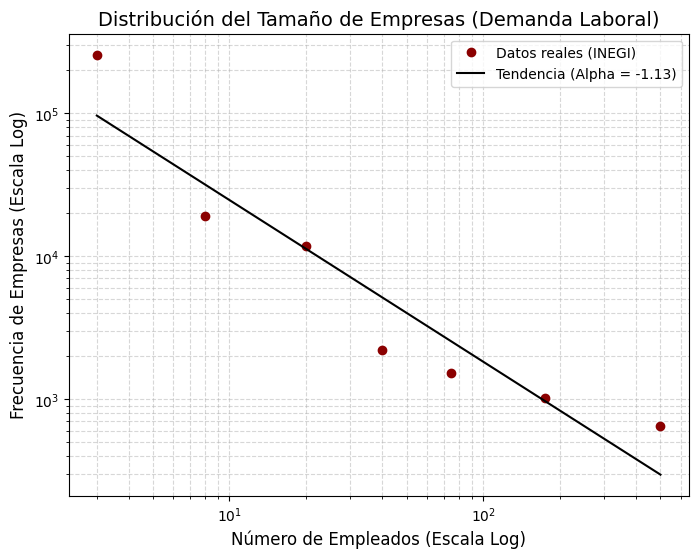

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar el archivo maestro
ruta_nacional = r"C:\Users\Yaveh\Desktop\Investigación cora\DENUE DATASET\denue_nacional_completo.csv"
df_nacional = pd.read_csv(ruta_nacional, encoding='utf-8-sig', low_memory=False)

# 2. Filtrar por Estado usando el NOMBRE en lugar del número
nombre_estado = "GUANAJUATO" # Puedes cambiarlo por "JALISCO", "NUEVO LEON", etc.

# Forzamos todo a texto, ignoramos mayúsculas/minúsculas y filtramos
df_local = df_nacional[
    df_nacional['entidad'].astype(str).str.contains(nombre_estado, case=False, na=False)
].copy()

print(f"Empresas analizadas en {nombre_estado}: {len(df_local):,}")
if len(df_local) == 0:
    print("¡Advertencia! No se encontraron empresas. Revisa cómo está escrito el nombre en el CSV.")

# 3. Contar la frecuencia de cada tamaño de empresa
distribucion = df_local['tamano_numerico'].value_counts().reset_index()
distribucion.columns = ['tamano_empleados', 'frecuencia']
distribucion = distribucion.sort_values(by='tamano_empleados')

# 4. Calcular el exponente de la Ley de Potencia (Power Law)
# Para esto, sacamos el logaritmo (base 10) de ambas variables
log_x = np.log10(distribucion['tamano_empleados'])
log_y = np.log10(distribucion['frecuencia'])

# Hacemos una regresión lineal (polinomio de grado 1) sobre los logaritmos
# np.polyfit devuelve [pendiente, intersección]
coeficientes = np.polyfit(log_x, log_y, 1)
exponente_alpha = coeficientes[0]  # La pendiente es nuestro exponente de la Ley de Potencia

print(f"El exponente de la Ley de Potencia (Alpha) es: {exponente_alpha:.4f}")

# 5. Graficar la Ley de Potencia con la línea de tendencia
plt.figure(figsize=(8, 6))

# Gráfico de dispersión original en escala logarítmica
plt.loglog(distribucion['tamano_empleados'], distribucion['frecuencia'], 
           marker='o', linestyle='none', color='darkred', label='Datos reales (INEGI)')

# Línea de tendencia matemática
tendencia_y = 10**(coeficientes[1]) * distribucion['tamano_empleados']**(exponente_alpha)
plt.loglog(distribucion['tamano_empleados'], tendencia_y, 
           linestyle='-', color='black', label=f'Tendencia (Alpha = {exponente_alpha:.2f})')

plt.title('Distribución del Tamaño de Empresas (Demanda Laboral)', fontsize=14)
plt.xlabel('Número de Empleados (Escala Log)', fontsize=12)
plt.ylabel('Frecuencia de Empresas (Escala Log)', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()

plt.show()

In [6]:
# Suponiendo que tu base de datos cruzada se llama 'panel_final'
# Vamos a extraer 5 filas al azar para ver casos reales

columnas_clave = ['ent', 'con', 'v_sel', 'n_ren', 'eda', 'clase2_t1', 'clase2_t2', 'ing_x_hrs_t1', 'ing_x_hrs_t2']

# Mostrar 5 ejemplos reales de tu panel
ejemplos_reales = panel_final[columnas_clave].head(5)
print(ejemplos_reales.to_string(index=False))

KeyError: "['eda'] not in index"